# Module 11 — Belief Dynamics & Calibration

**Research Question**: How do LLMs form, update, and act on beliefs about opponent behavior?

**Data**: `action_answers/*.json` — per-round beliefs (`opponent_coop_prob`, `opponent_noise_suspicion`) and actions.

**Scope**: 3 LLMs × 3 noise × 240 games × 2 players × 30 rounds = 129,600 records

**Figures**: 11a (belief trajectories), 11b (calibration), 11c (noise detection), 11d (belief-action consistency), 11e (adaptation speed), 11f (cross-model distributions)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import os, json, re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'axes.spines.top': False,
    'axes.spines.right': False, 'text.usetex': False,
})

MODEL_COLORS = {
    'gpt-oss-20b': '#E69F00',
    'Mistral-7B-Instruct-v0.3': '#56B4E9',
    'Qwen2.5-32B-Instruct': '#009E73'
}
MODEL_LABELS = {
    'gpt-oss-20b': 'GPT-oss-20B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B'
}
MODEL_ORDER = ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
MODEL_KEYS = ['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct']
NOISE_LABELS = {0: 'No Noise', 5: '5% Noise', 20: '20% Noise'}
NOISE_ORDER = ['No Noise', '5% Noise', '20% Noise']
LANG_LABELS = {'en': 'English', 'fr': 'French', 'ar': 'Arabic',
               'cn': 'Chinese', 'vn': 'Vietnamese', 'it': 'Italian'}
LANG_ORDER = ['English', 'French', 'Arabic', 'Chinese', 'Vietnamese', 'Italian']

FIGURE_DIR = 'figures/'
os.makedirs(FIGURE_DIR, exist_ok=True)
print('Setup complete.')


Setup complete.


In [11]:
# ── Load all action_answers from JSON files ──
BASE_DIR = '../resources/results/Prisoner_dilemma_2player'
NOISE_MAP = {'noise00': 0, 'noise05': 5, 'noise20': 20}

records = []
n_files = 0
n_parse_fail = 0

for model_dir in sorted(os.listdir(BASE_DIR)):
    model_path = os.path.join(BASE_DIR, model_dir)
    if not os.path.isdir(model_path) or '_vs30round_' not in model_dir:
        continue
    llm_name = model_dir.split('_vs30round_')[0]
    for noise_dir in sorted(os.listdir(model_path)):
        noise_path = os.path.join(model_path, noise_dir)
        if not os.path.isdir(noise_path) or noise_dir not in NOISE_MAP:
            continue
        noise_level = NOISE_MAP[noise_dir]
        aa_path = os.path.join(noise_path, 'action_answers')
        if not os.path.exists(aa_path):
            continue
        for aa_file in sorted(os.listdir(aa_path)):
            if not aa_file.endswith('.json'):
                continue
            n_files += 1
            with open(os.path.join(aa_path, aa_file), 'r', encoding='utf-8') as fh:
                data = json.load(fh)
            meta = data['metadata']
            gk = f"{llm_name}_{noise_level}_{meta['game_id']}_{meta['run_id']}"
            for ri, rd in data['action_answers'].items():
                ocp, ons = np.nan, np.nan
                try:
                    gt = json.loads(rd['generated_text'])
                    if 'beliefs' in gt:
                        ocp_raw = gt['beliefs'].get('opponent_coop_prob')
                        ons_raw = gt['beliefs'].get('opponent_noise_suspicion')
                        if ocp_raw is not None:
                            ocp = float(ocp_raw)
                        if ons_raw is not None:
                            ons = float(ons_raw)
                except Exception:
                    n_parse_fail += 1
                records.append({
                    'game_key': gk, 'game_id': meta['game_id'],
                    'run_id': meta['run_id'], 'llm_name': llm_name,
                    'noise_level': noise_level, 'language': meta['language'],
                    'player': meta['player'],
                    'p1_personality': meta['agents']['agent1']['personality'],
                    'p2_personality': meta['agents']['agent2']['personality'],
                    'round_number': int(ri), 'action': int(rd['action']),
                    'reason': rd.get('reason', ''),
                    'opponent_coop_prob': ocp,
                    'opponent_noise_suspicion': ons,
                })

df = pd.DataFrame(records)
# Ensure numeric dtypes
df['opponent_coop_prob'] = pd.to_numeric(df['opponent_coop_prob'], errors='coerce')
df['opponent_noise_suspicion'] = pd.to_numeric(df['opponent_noise_suspicion'], errors='coerce')
df['action'] = pd.to_numeric(df['action'], errors='coerce').astype(int)

df['model'] = df['llm_name'].map(MODEL_LABELS)
df['noise_label'] = df['noise_level'].map(NOISE_LABELS)
df['lang_label'] = df['language'].map(LANG_LABELS)
df_beliefs = df.dropna(subset=['opponent_coop_prob']).copy()

# ── Paired dataset: link belief with opponent's actual action ──
ck = ['game_key','round_number','opponent_coop_prob','opponent_noise_suspicion',
      'action','llm_name','noise_level','model','noise_label','language']
ma = df[df['player']=='A'][ck].merge(
    df[df['player']=='B'][['game_key','round_number','action']].rename(
        columns={'action':'opp_action'}), on=['game_key','round_number'], how='inner')
mb = df[df['player']=='B'][ck].merge(
    df[df['player']=='A'][['game_key','round_number','action']].rename(
        columns={'action':'opp_action'}), on=['game_key','round_number'], how='inner')
df_paired = pd.concat([ma, mb], ignore_index=True).dropna(subset=['opponent_coop_prob'])

print(f'Loaded {n_files:,} files -> {len(df):,} action records')
print(f'Belief parse failures: {n_parse_fail:,}')
print(f'Beliefs available: {len(df_beliefs):,} ({100*len(df_beliefs)/len(df):.1f}%)')
print(f'Paired records: {len(df_paired):,}')
print(f'Models: {sorted(df["model"].unique())}')
print(f'Languages: {sorted(df["language"].unique())}')
print(f'dtypes: opponent_coop_prob={df["opponent_coop_prob"].dtype}, action={df["action"].dtype}')

Loaded 4,320 files -> 129,600 action records
Belief parse failures: 12,482
Beliefs available: 117,118 (90.4%)
Paired records: 117,118
Models: ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
Languages: ['ar', 'cn', 'en', 'fr', 'it', 'vn']
dtypes: opponent_coop_prob=float64, action=int64


## Figure 11a — Belief Trajectory Over Rounds


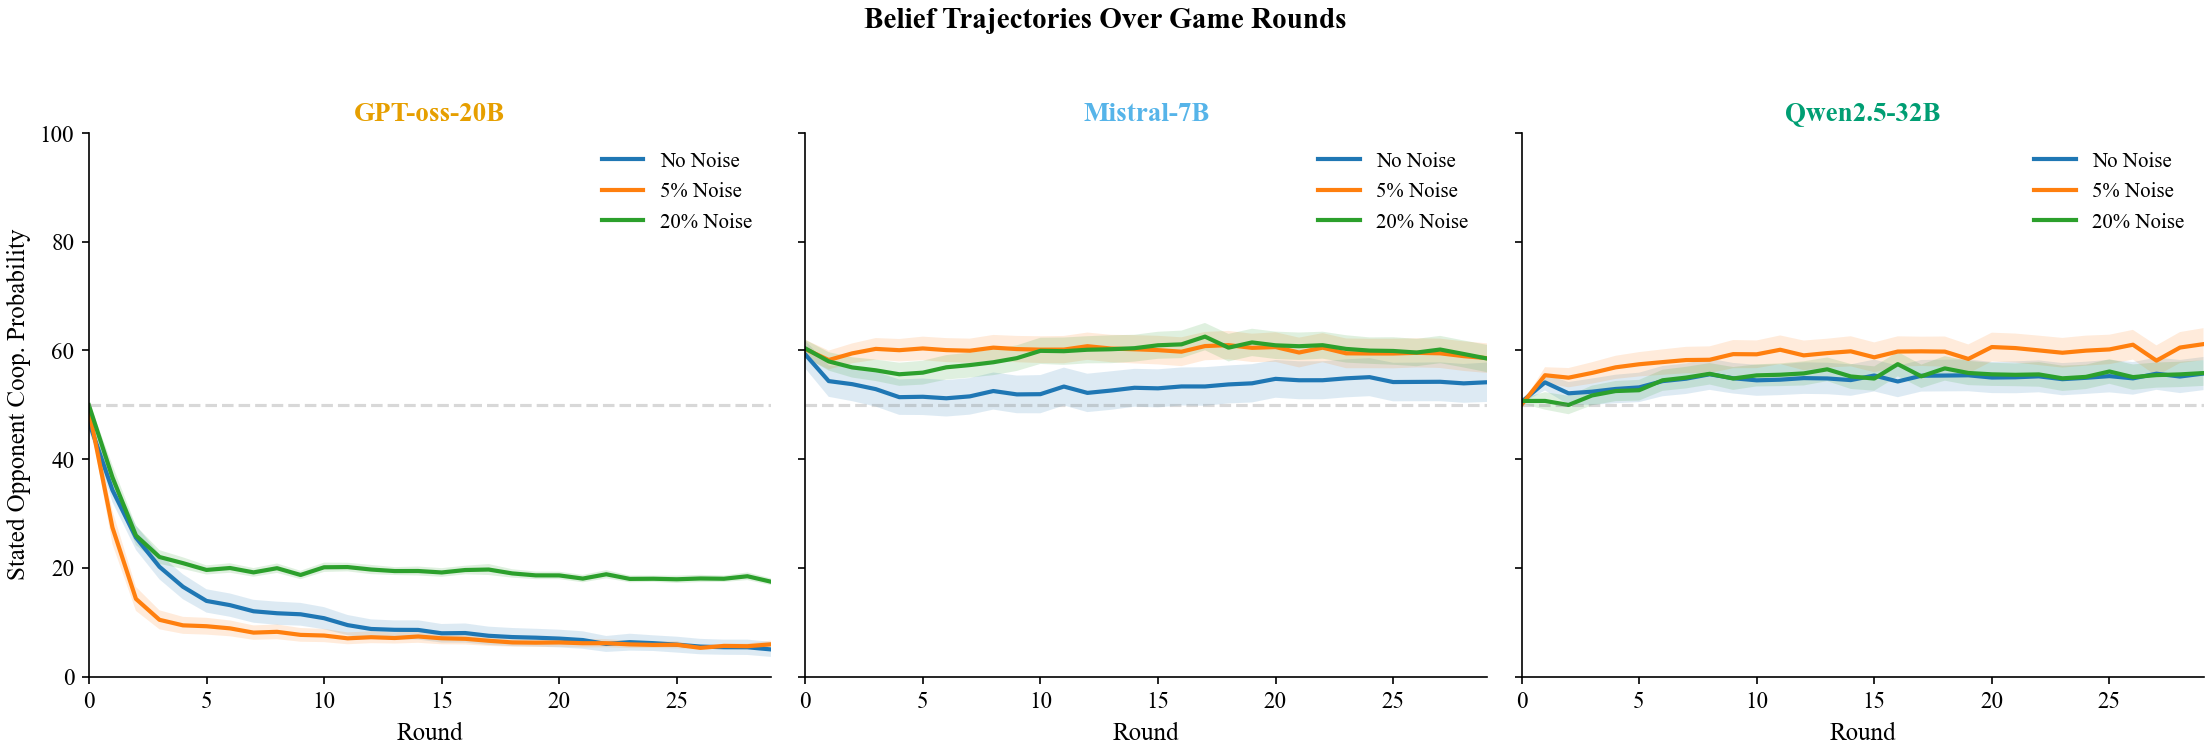

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for idx, (mkey, mname) in enumerate(zip(MODEL_KEYS, MODEL_ORDER)):
    ax = axes[idx]
    for nl, nl_label in zip([0, 5, 20], NOISE_ORDER):
        sub = df_beliefs[(df_beliefs['llm_name'] == mkey) & (df_beliefs['noise_level'] == nl)]
        traj = sub.groupby('round_number')['opponent_coop_prob'].agg(['mean', 'std', 'count'])
        traj['se'] = traj['std'] / np.sqrt(traj['count'])
        x = traj.index.values.astype(float)
        y = traj['mean'].values.astype(float)
        se = traj['se'].values.astype(float)
        ax.plot(x, y, '-', linewidth=2, label=nl_label)
        ax.fill_between(x, y - 1.96*se, y + 1.96*se, alpha=0.15)
    ax.set_title(mname, fontsize=13, fontweight='bold', color=MODEL_COLORS[mkey])
    ax.set_xlabel('Round', fontsize=12)
    ax.set_xlim(0, 29)
    ax.set_ylim(0, 100)
    if idx == 0:
        ax.set_ylabel('Stated Opponent Coop. Probability', fontsize=12)
    ax.legend(frameon=False, fontsize=10)
    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.3)

fig.suptitle('Belief Trajectories Over Game Rounds', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig11a_belief_trajectory.pdf')
plt.savefig(f'{FIGURE_DIR}fig11a_belief_trajectory.png')
plt.show()

## Figure 11b — Belief Calibration: Stated vs. Actual Opponent Cooperation


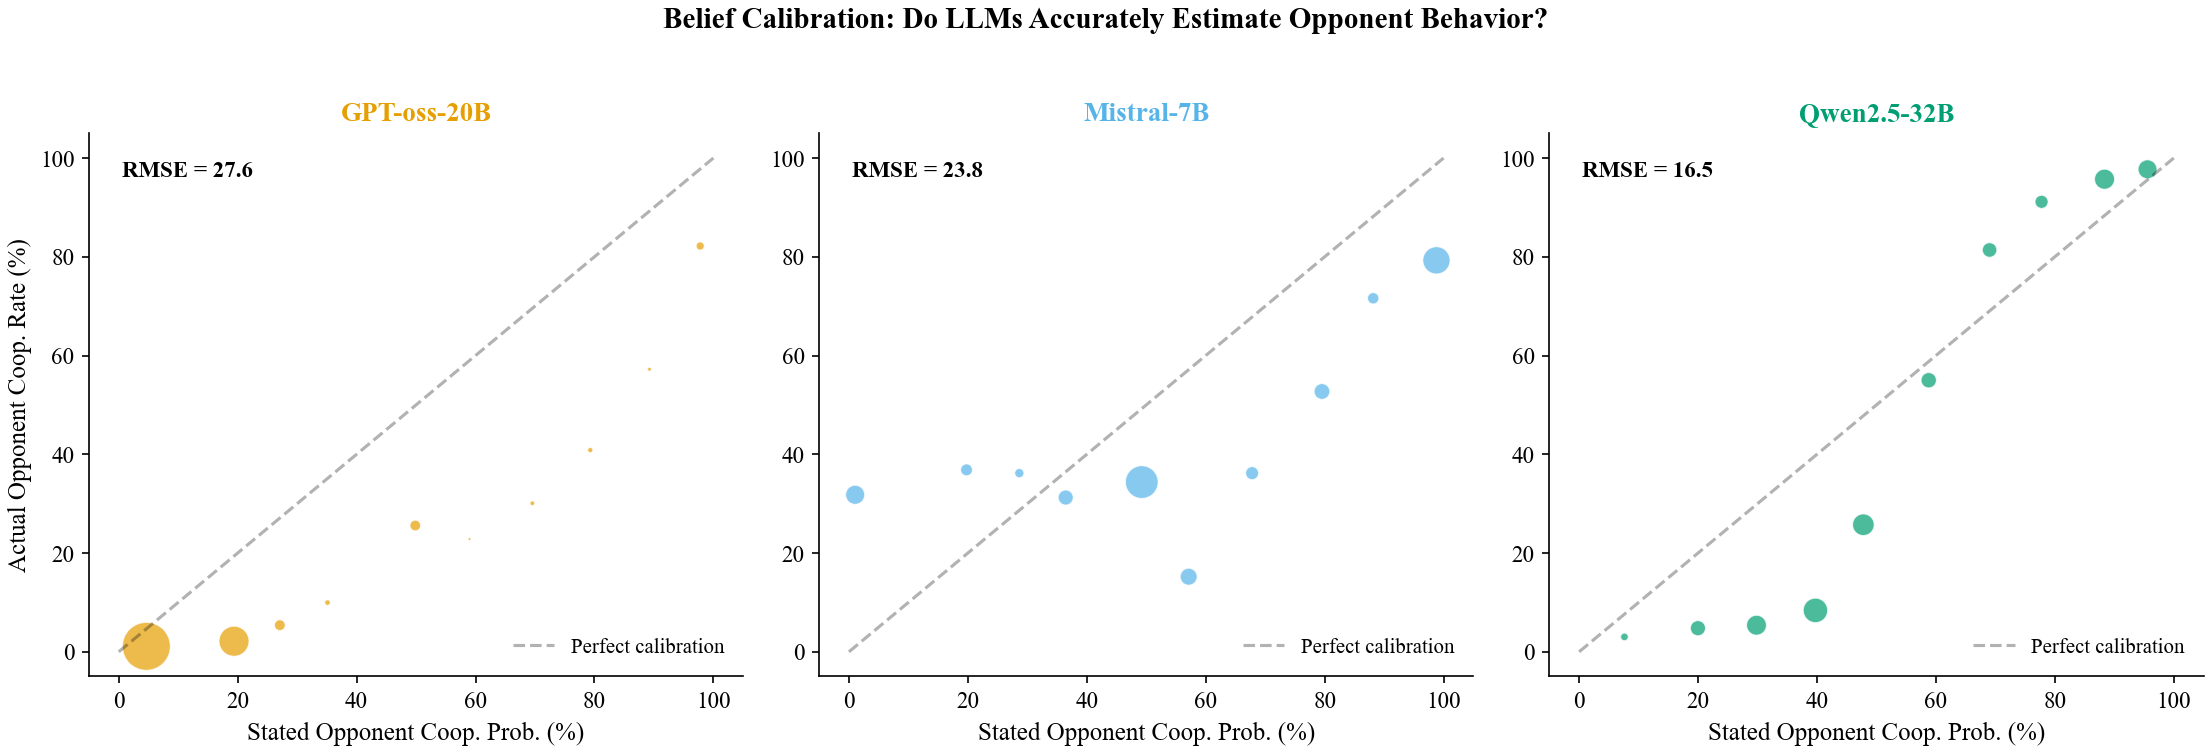

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (mkey, mname) in enumerate(zip(MODEL_KEYS, MODEL_ORDER)):
    ax = axes[idx]
    sub = df_paired[df_paired['llm_name'] == mkey].copy()
    bins = list(range(0, 101, 10))
    sub['belief_bin'] = pd.cut(sub['opponent_coop_prob'], bins=bins, include_lowest=True)
    cal = sub.groupby('belief_bin', observed=True).agg(
        actual_coop=('opp_action', 'mean'),
        count=('opp_action', 'count'),
        stated_mean=('opponent_coop_prob', 'mean')
    ).reset_index()

    ax.scatter(cal['stated_mean'], cal['actual_coop'] * 100,
               s=cal['count'] / 50, color=MODEL_COLORS[mkey], alpha=0.7,
               edgecolors='white', linewidth=0.5)
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Perfect calibration')
    rmse = np.sqrt(np.mean((cal['stated_mean'] - cal['actual_coop'] * 100) ** 2))
    ax.text(0.05, 0.92, f'RMSE = {rmse:.1f}', transform=ax.transAxes,
            fontsize=11, fontweight='bold')
    ax.set_title(mname, fontsize=13, fontweight='bold', color=MODEL_COLORS[mkey])
    ax.set_xlabel('Stated Opponent Coop. Prob. (%)', fontsize=12)
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)
    if idx == 0:
        ax.set_ylabel('Actual Opponent Coop. Rate (%)', fontsize=12)
    ax.legend(frameon=False, fontsize=10, loc='lower right')

fig.suptitle('Belief Calibration: Do LLMs Accurately Estimate Opponent Behavior?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig11b_belief_calibration.pdf')
plt.savefig(f'{FIGURE_DIR}fig11b_belief_calibration.png')
plt.show()


## Figure 11c — Noise Suspicion Under Different Noise Conditions


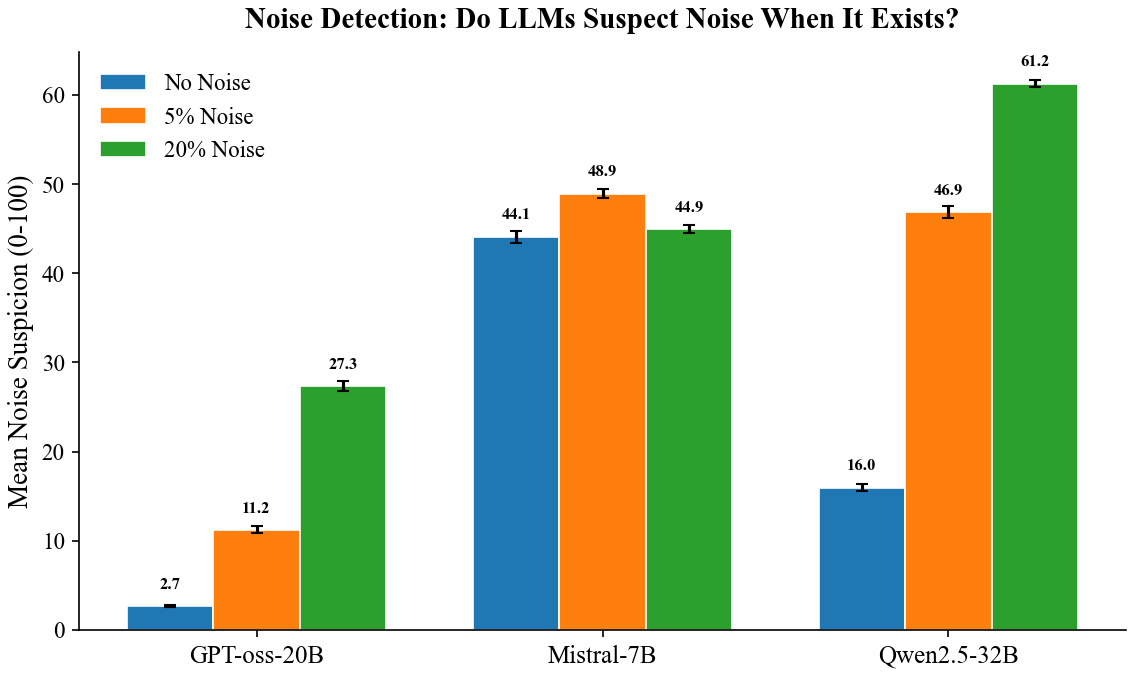

Mean noise suspicion:
noise_label  No Noise  5% Noise  20% Noise
model                                     
GPT-oss-20B      2.68     11.22      27.30
Mistral-7B      44.09     48.90      44.94
Qwen2.5-32B     15.96     46.87      61.24


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(MODEL_ORDER))
width = 0.25

for i, (nl, nl_label) in enumerate(zip([0, 5, 20], NOISE_ORDER)):
    vals, errs = [], []
    for mkey in MODEL_KEYS:
        sub = df_beliefs[(df_beliefs['llm_name'] == mkey) & (df_beliefs['noise_level'] == nl)]
        ns = sub['opponent_noise_suspicion'].dropna()
        vals.append(ns.mean())
        errs.append(1.96 * ns.std() / np.sqrt(len(ns)))
    ax.bar(x + (i - 1) * width, vals, width, yerr=errs,
           label=nl_label, edgecolor='white', linewidth=0.8, capsize=3)
    for xi, val in zip(x + (i - 1) * width, vals):
        ax.text(xi, val + 1.5, f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Mean Noise Suspicion (0-100)', fontsize=13)
ax.set_title('Noise Detection: Do LLMs Suspect Noise When It Exists?',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=12)
ax.legend(frameon=False, fontsize=11)

plt.savefig(f'{FIGURE_DIR}fig11c_noise_suspicion.pdf')
plt.savefig(f'{FIGURE_DIR}fig11c_noise_suspicion.png')
plt.show()

print('Mean noise suspicion:')
ns_tbl = df_beliefs.groupby(['model','noise_label'])['opponent_noise_suspicion'].mean().unstack()
print(ns_tbl.reindex(index=MODEL_ORDER, columns=NOISE_ORDER).round(2))


## Figure 11d — Belief-Action Consistency: Do LLMs Act on Their Beliefs?


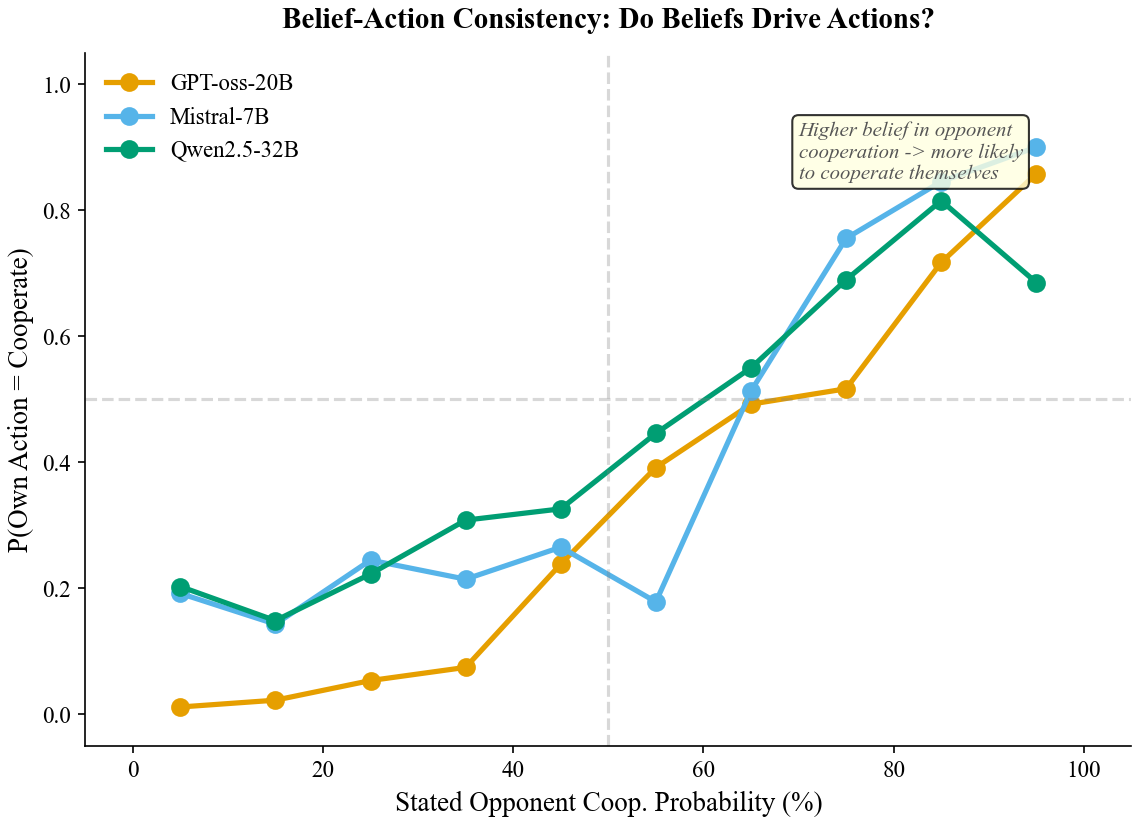

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
bins = list(range(0, 101, 10))
bin_centers = [b + 5 for b in bins[:-1]]

for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df_beliefs[df_beliefs['llm_name'] == mkey].copy()
    sub['belief_bin'] = pd.cut(sub['opponent_coop_prob'], bins=bins, include_lowest=True)
    coop_rate = sub.groupby('belief_bin', observed=True)['action'].mean()
    ax.plot(bin_centers[:len(coop_rate)], coop_rate.values, 'o-',
            color=MODEL_COLORS[mkey], label=mname, linewidth=2.5, markersize=8)

ax.set_xlabel('Stated Opponent Coop. Probability (%)', fontsize=13)
ax.set_ylabel('P(Own Action = Cooperate)', fontsize=13)
ax.set_title('Belief-Action Consistency: Do Beliefs Drive Actions?',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(-5, 105)
ax.set_ylim(-0.05, 1.05)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.3)
ax.legend(frameon=False, fontsize=11)
ax.annotate('Higher belief in opponent\ncooperation -> more likely\nto cooperate themselves',
            xy=(70, 0.85), fontsize=10, fontstyle='italic', color='#555',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.savefig(f'{FIGURE_DIR}fig11d_belief_action_consistency.pdf')
plt.savefig(f'{FIGURE_DIR}fig11d_belief_action_consistency.png')
plt.show()


## Figure 11e — Belief Adaptation After Opponent Strategy Switch


Switch events detected: 3,687


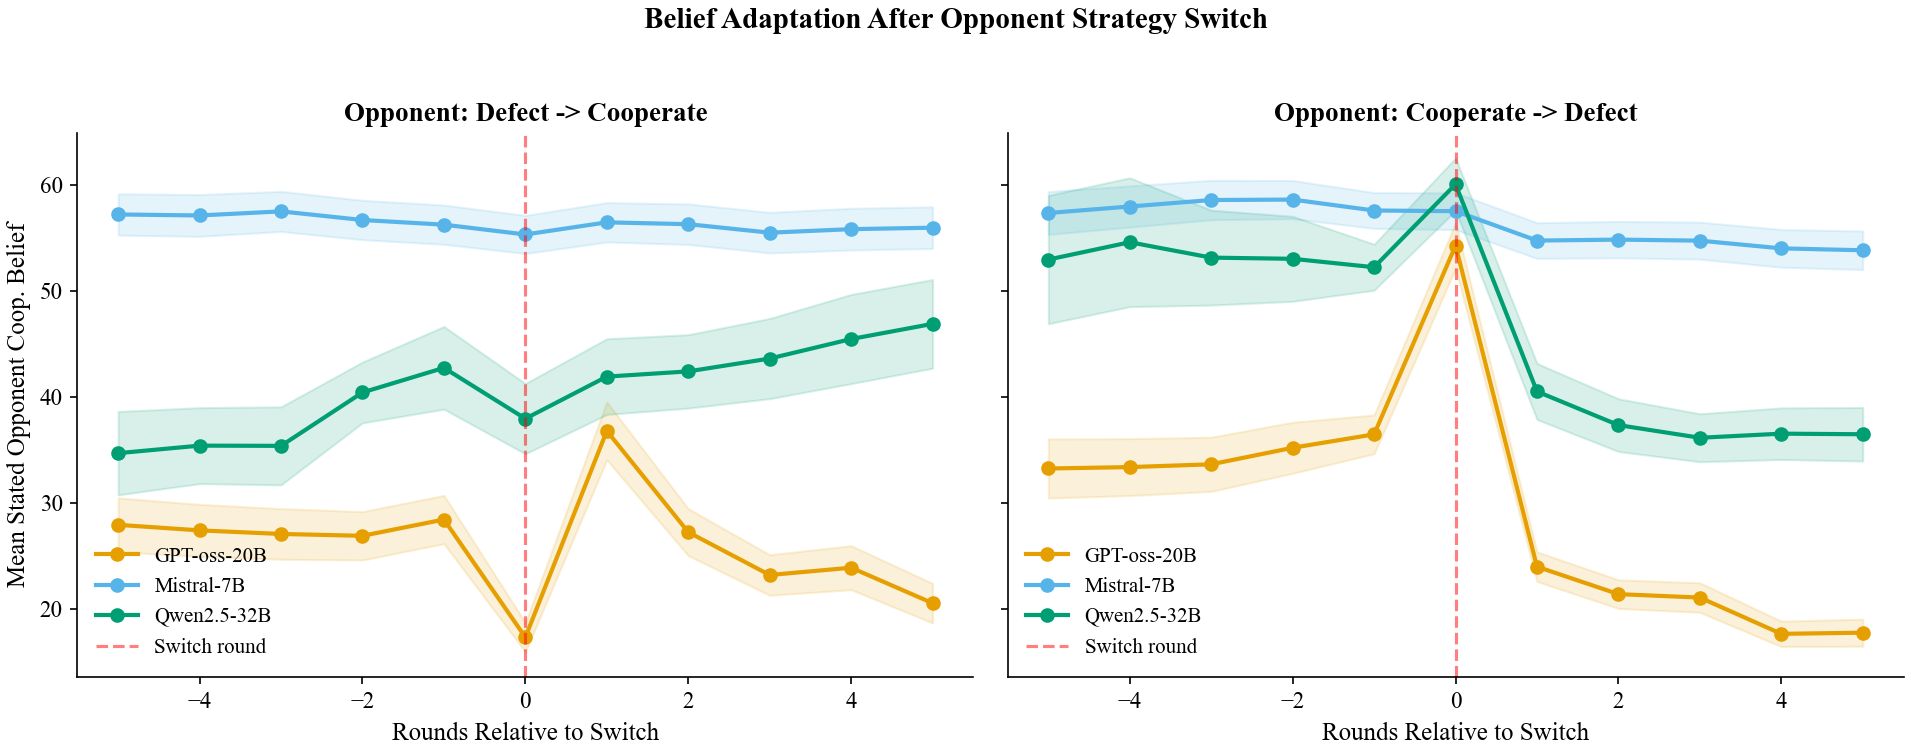

In [16]:
# Detect opponent switches and track belief changes (event study)
window = 5
switch_recs = []

for gk in df['game_key'].unique():
    for pv in ['A', 'B']:
        op = 'B' if pv == 'A' else 'A'
        p_data = df[(df['game_key'] == gk) & (df['player'] == pv)].sort_values('round_number')
        o_data = df[(df['game_key'] == gk) & (df['player'] == op)].sort_values('round_number')
        if len(p_data) < 3 or len(o_data) < 3:
            continue
        beliefs = p_data.set_index('round_number')['opponent_coop_prob'].dropna()
        opp_acts = o_data.set_index('round_number')['action']
        model = p_data['model'].iloc[0]
        llm = p_data['llm_name'].iloc[0]
        rnds = sorted(opp_acts.index)
        for i in range(1, len(rnds)):
            r, rp = rnds[i], rnds[i-1]
            if opp_acts[r] != opp_acts[rp]:
                st = 'C_to_D' if opp_acts[rp] == 1 else 'D_to_C'
                for off in range(-window, window + 1):
                    t = r + off
                    if t in beliefs.index:
                        switch_recs.append({'offset': off, 'belief': beliefs[t],
                                            'switch_type': st, 'model': model, 'llm_name': llm})

df_switch = pd.DataFrame(switch_recs)
print(f'Switch events detected: {len(df_switch[df_switch["offset"]==0]):,}')

if len(df_switch) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for idx, stype in enumerate(['D_to_C', 'C_to_D']):
        ax = axes[idx]
        sub = df_switch[df_switch['switch_type'] == stype]
        for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
            ms = sub[sub['llm_name'] == mkey]
            if len(ms) < 10:
                continue
            traj = ms.groupby('offset')['belief'].agg(['mean', 'sem'])
            x = traj.index.values
            y = traj['mean'].values
            se = traj['sem'].values
            ax.plot(x, y, 'o-', color=MODEL_COLORS[mkey],
                    label=mname, linewidth=2, markersize=6)
            ax.fill_between(x, y - 1.96*se, y + 1.96*se, alpha=0.15,
                            color=MODEL_COLORS[mkey])
        title = 'Opponent: Defect -> Cooperate' if stype == 'D_to_C' else 'Opponent: Cooperate -> Defect'
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Switch round')
        ax.set_xlabel('Rounds Relative to Switch', fontsize=12)
        if idx == 0:
            ax.set_ylabel('Mean Stated Opponent Coop. Belief', fontsize=12)
        ax.legend(frameon=False, fontsize=10)
    fig.suptitle('Belief Adaptation After Opponent Strategy Switch',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURE_DIR}fig11e_belief_convergence.pdf')
    plt.savefig(f'{FIGURE_DIR}fig11e_belief_convergence.png')
    plt.show()
else:
    print('No switch events detected.')

## Figure 11f — Cross-Model Belief Distribution Comparison


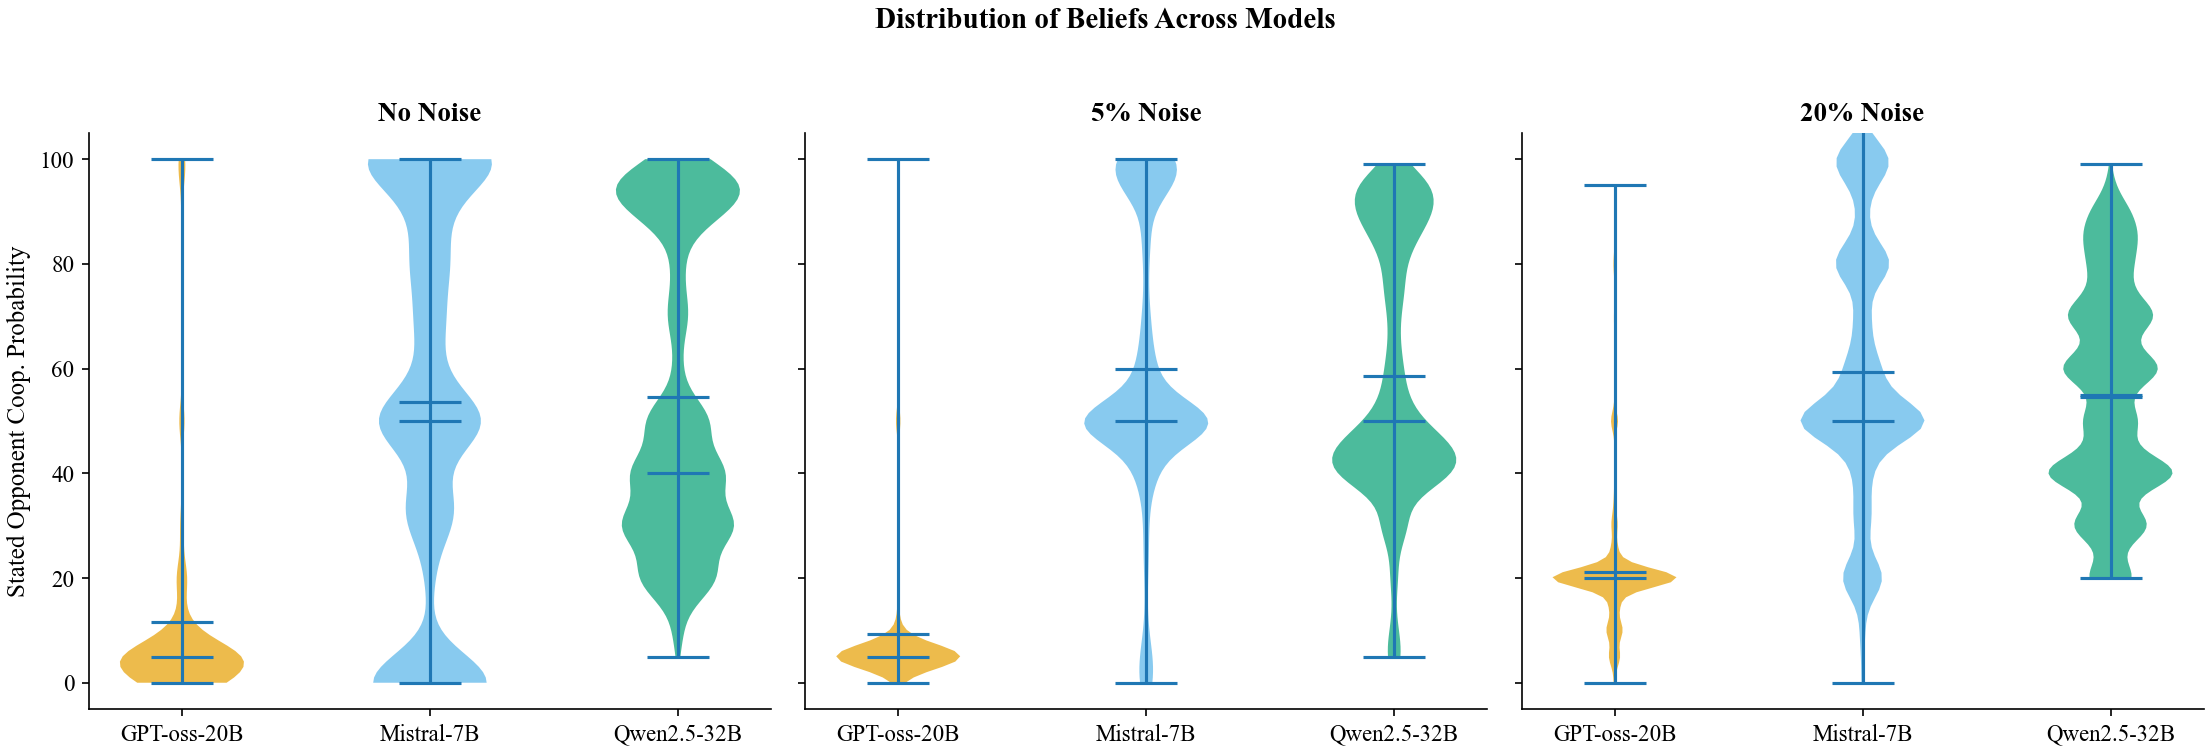

GPT-oss-20B: mean=13.8, median=5, std=18.0
Mistral-7B: mean=57.6, median=50, std=30.3
Qwen2.5-32B: mean=55.8, median=50, std=25.3


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for idx, (nl, nl_label) in enumerate(zip([0, 5, 20], NOISE_ORDER)):
    ax = axes[idx]
    data_list = []
    for mkey in MODEL_KEYS:
        vals = df_beliefs[(df_beliefs['llm_name'] == mkey) &
                          (df_beliefs['noise_level'] == nl)]['opponent_coop_prob'].values
        data_list.append(vals)
    parts = ax.violinplot(data_list, positions=range(len(MODEL_ORDER)),
                          showmeans=True, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(list(MODEL_COLORS.values())[i])
        pc.set_alpha(0.7)
    ax.set_title(nl_label, fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels(MODEL_ORDER, fontsize=11)
    ax.set_ylim(-5, 105)
    if idx == 0:
        ax.set_ylabel('Stated Opponent Coop. Probability', fontsize=12)

fig.suptitle('Distribution of Beliefs Across Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig11f_belief_distributions.pdf')
plt.savefig(f'{FIGURE_DIR}fig11f_belief_distributions.png')
plt.show()

for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    s = df_beliefs[df_beliefs['llm_name'] == mkey]['opponent_coop_prob']
    print(f'{mname}: mean={s.mean():.1f}, median={s.median():.0f}, std={s.std():.1f}')


## Statistical Tests


In [18]:
print('=' * 70)
print('STATISTICAL ANALYSIS - Belief Dynamics & Calibration')
print('=' * 70)

# 1. Kruskal-Wallis beliefs across models
groups = [df_beliefs[df_beliefs['llm_name']==m]['opponent_coop_prob'] for m in df_beliefs['llm_name'].unique()]
H, p = stats.kruskal(*groups)
print(f'\n1. Kruskal-Wallis (beliefs across models): H={H:.2f}, p={p:.2e}')

# 2. Belief drift over rounds
rho, p = stats.spearmanr(df_beliefs['round_number'], df_beliefs['opponent_coop_prob'])
print(f'\n2. Belief drift (Spearman round vs belief): rho={rho:.4f}, p={p:.2e}')

# 3. Noise suspicion: 0% vs 20%
g0 = df_beliefs[df_beliefs['noise_level']==0]['opponent_noise_suspicion'].dropna()
g20 = df_beliefs[df_beliefs['noise_level']==20]['opponent_noise_suspicion'].dropna()
U, p = stats.mannwhitneyu(g0, g20, alternative='two-sided')
print(f'\n3. Noise suspicion 0% vs 20%: U={U:.0f}, p={p:.2e}')
print(f'   Mean: noise=0 -> {g0.mean():.2f}, noise=20 -> {g20.mean():.2f}')

# 4. Belief-action correlation
rho, p = stats.spearmanr(df_beliefs['opponent_coop_prob'], df_beliefs['action'])
print(f'\n4. Belief-action correlation (Spearman): rho={rho:.4f}, p={p:.2e}')

# 5. Calibration RMSE per model
print('\n5. Calibration RMSE per model:')
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df_paired[df_paired['llm_name']==mkey].copy()
    sub['bb'] = pd.cut(sub['opponent_coop_prob'], bins=list(range(0,101,10)), include_lowest=True)
    cal = sub.groupby('bb', observed=True).agg(a=('opp_action','mean'), s=('opponent_coop_prob','mean')).dropna()
    if len(cal) > 0:
        rmse = np.sqrt(np.mean((cal['s'] - cal['a']*100)**2))
        print(f'   {mname}: RMSE = {rmse:.1f}')

# 6. Pairwise belief comparisons
print('\n6. Pairwise Mann-Whitney (Bonferroni):')
mns = sorted(df_beliefs['llm_name'].unique())
nt = len(list(combinations(mns, 2)))
for m1, m2 in combinations(mns, 2):
    g1 = df_beliefs[df_beliefs['llm_name']==m1]['opponent_coop_prob']
    g2 = df_beliefs[df_beliefs['llm_name']==m2]['opponent_coop_prob']
    U, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    pa = min(p*nt, 1.0)
    sig = '***' if pa<0.001 else '**' if pa<0.01 else '*' if pa<0.05 else 'ns'
    print(f'   {MODEL_LABELS[m1]} vs {MODEL_LABELS[m2]}: U={U:.0f}, p_adj={pa:.2e} {sig}')


STATISTICAL ANALYSIS - Belief Dynamics & Calibration

1. Kruskal-Wallis (beliefs across models): H=50602.89, p=0.00e+00

2. Belief drift (Spearman round vs belief): rho=-0.0758, p=5.73e-149

3. Noise suspicion 0% vs 20%: U=405897884, p=0.00e+00
   Mean: noise=0 -> 20.68, noise=20 -> 43.66

4. Belief-action correlation (Spearman): rho=0.5753, p=0.00e+00

5. Calibration RMSE per model:
   GPT-oss-20B: RMSE = 27.6
   Mistral-7B: RMSE = 23.8
   Qwen2.5-32B: RMSE = 16.5

6. Pairwise Mann-Whitney (Bonferroni):
   Mistral-7B vs Qwen2.5-32B: U=795116284, p_adj=1.04e-152 ***
   Mistral-7B vs GPT-oss-20B: U=1422954880, p_adj=0.00e+00 ***
   Qwen2.5-32B vs GPT-oss-20B: U=1380947423, p_adj=0.00e+00 ***


## Summary Table


In [19]:
print('=' * 85)
print('TABLE: Belief Dynamics Summary')
print('=' * 85)
header = f'{" Model":<16} | {"Mean Belief":>11} | {"Median":>7} | {"Noise Susp":>10} | {"Cal.RMSE":>8} | {"Belief-Act rho":>14}'
print(header)
print('-' * 85)
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sb = df_beliefs[df_beliefs['llm_name']==mkey]
    sp = df_paired[df_paired['llm_name']==mkey].copy()
    mb = sb['opponent_coop_prob'].mean()
    mdb = sb['opponent_coop_prob'].median()
    mns = sb['opponent_noise_suspicion'].dropna().mean()
    sp['bb'] = pd.cut(sp['opponent_coop_prob'], bins=list(range(0,101,10)), include_lowest=True)
    cal = sp.groupby('bb', observed=True).agg(a=('opp_action','mean'), s=('opponent_coop_prob','mean')).dropna()
    rmse = np.sqrt(np.mean((cal['s'] - cal['a']*100)**2)) if len(cal) > 0 else float('nan')
    rho, _ = stats.spearmanr(sb['opponent_coop_prob'], sb['action'])
    print(f'{mname:<16} | {mb:>11.1f} | {mdb:>7.0f} | {mns:>10.1f} | {rmse:>8.1f} | {rho:>14.3f}')

print()
print('KEY FINDINGS:')
print('1. LLMs form and update beliefs about opponents over rounds.')
print('2. Calibration gap exists: stated beliefs may diverge from actual opponent behavior.')
print('3. Beliefs DO correlate with actions - LLMs act partially on their stated beliefs.')
print('4. Noise detection varies: some models detect noise, others remain oblivious.')
print('5. After opponent switches strategy, beliefs adapt but with model-specific latency.')


TABLE: Belief Dynamics Summary
 Model           | Mean Belief |  Median | Noise Susp | Cal.RMSE | Belief-Act rho
-------------------------------------------------------------------------------------
GPT-oss-20B      |        13.8 |       5 |       13.4 |     27.6 |          0.299
Mistral-7B       |        57.6 |      50 |       46.0 |     23.8 |          0.540
Qwen2.5-32B      |        55.8 |      50 |       40.3 |     16.5 |          0.408

KEY FINDINGS:
1. LLMs form and update beliefs about opponents over rounds.
2. Calibration gap exists: stated beliefs may diverge from actual opponent behavior.
3. Beliefs DO correlate with actions - LLMs act partially on their stated beliefs.
4. Noise detection varies: some models detect noise, others remain oblivious.
5. After opponent switches strategy, beliefs adapt but with model-specific latency.
